In [ ]:
from datetime import timedelta
import matplotlib.pyplot as plt
from alpaca.data.historical import StockHistoricalDataClient

from Data_Handling import *
from Credentials import ALPACA_API_KEY, ALPACA_SECRET_KEY
client = StockHistoricalDataClient(ALPACA_API_KEY, ALPACA_SECRET_KEY)

In [3]:
# Configuration
symbol = "SPY"
start_date = "2024-01-01"
end_date = "2024-12-31"
optimization_window_days = 3
execution_window_days = 1
timeframe_unit = "Minute"
multiplier = 1


entry_thresholds = np.arange(5,40,5)
exit_thresholds = np.arange (60,95,5)
rsi_periods = np.arange (7, 98, 7)

In [4]:
# 1. Load Data
data = get_data_auto(symbol, start=start_date, end=end_date, timeframe_unit=timeframe_unit, multiplier=multiplier)

In [5]:
#2. Define Strategy
@njit
def compute_rsi(close, period):
    gains = np.zeros_like(close)
    losses = np.zeros_like(close)

    for i in range(1, len(close)):
        change = close[i] - close[i - 1]
        if change > 0:
            gains[i] = change
        else:
            losses[i] = -change

    avg_gain = np.empty_like(close)
    avg_loss = np.empty_like(close)
    avg_gain[:period] = np.nan
    avg_loss[:period] = np.nan

    avg_gain[period] = np.mean(gains[1:period+1])
    avg_loss[period] = np.mean(losses[1:period+1])

    for i in range(period + 1, len(close)):
        avg_gain[i] = (avg_gain[i - 1] * (period - 1) + gains[i]) / period
        avg_loss[i] = (avg_loss[i - 1] * (period - 1) + losses[i]) / period

    
    rs = avg_gain / (avg_loss + 1e-10)
    rsi = 100 - (100 / (1 + rs))
    return rsi

def logic(rsi_vals, entry_threshold, exit_threshold):
    signals = np.where(rsi_vals<entry_threshold,1,0)
    return np.where(rsi_vals>exit_threshold,-1,signals)

def run_RSI_strat1(close, entry_threshold, exit_threshold, rsi_period):
    if rsi_period >= len(close) - 1:
        return np.full_like(close, 0) 
    rsi_vals = compute_rsi(close, rsi_period)
    return logic(rsi_vals, entry_threshold, exit_threshold)

RSI_strat1 = IndicatorFactory(
    class_name="RSI1",
    short_name="rsi1",
    input_names=["close"],
    param_names=["entry_threshold","exit_threshold","rsi_period"],
    output_names=["signals"] 
    ).from_apply_func(
        run_RSI_strat1
        )

In [6]:
#3. Walk-forward Loop
dates = data.index.normalize().unique()
results=[]
all_trades=[]

for i in range(optimization_window_days, len(dates)- execution_window_days):
    training_start = dates[i - optimization_window_days]
    training_end = dates[i] - timedelta(seconds=1)
    test_start = dates[i]
    test_end = dates[i+ execution_window_days]

    training_data = data.loc[training_start:training_end]
    test_data = data.loc[test_start:test_end]

    #3.1 Optimize on traning dates over parameters
    call_signals = RSI_strat1.run(
        close = training_data["Close"],
        entry_threshold = entry_thresholds,
        exit_threshold = exit_thresholds,
        rsi_period = rsi_periods,
        param_product = True
        )

    pf_test = vbt.Portfolio.from_signals(
        close = training_data["Close"],
        entries = (call_signals.signals == 1.0),
        exits = (call_signals.signals == -1.0),
        size = 1,
        sl_stop = 0.01,
        tp_stop = 0.02 ,
        freq = "m"
        )
    
    best_params, best_value, best_pf = Overfitting_reduction(pf_test, objective_function=None, smoothing_size=3, filter_threshold=0.0)

    #3.2 Run with optimised parameters
    optimum_signals = RSI_strat1.run(
        close = test_data["Close"],
        entry_threshold = best_params["rsi1_entry_threshold"],
        exit_threshold = best_params["rsi1_exit_threshold"],
        rsi_period = best_params["rsi1_rsi_period"]
        )
    pf_results = vbt.Portfolio.from_signals(
        close=test_data["Close"],
        entries = (optimum_signals.signals == 1.0),
        exits = (optimum_signals.signals == -1.0),
        size = 1,
        sl_stop = 0.01,
        tp_stop = 0.02,
        freq = "m"
        )
    all_trades.append(pf_results)
    results.append({
        "date": test_start,
        "params": best_params,
        "return": pf_results.total_return(),
        "best_value": best_value
        })

    print(str(best_value) + " = " + str(pf_results.total_return()))



0.004875315375256306 = 0.0006813335348805083
0.004714525569357659 = 0.0
0.007065588484193395 = 0.012964553474919
0.01857851829718289 = 0.0008953078218463872
0.015364085555371507 = 0.0
0.020934064461684245 = -0.0009441879983215529
0.009999633126107917 = -0.0008216230596895003
0.007428767019661278 = 0.0
0.0050357880629242876 = 0.0041641487527527945
0.008042439883878488 = -0.002306341380842696
0.004622261062177099 = 0.0007393324883818764
0.009075276458436483 = 0.012571092782639681
0.022554247620084192 = 0.0
0.01824966764930319 = -0.00012407204450056496
0.015878776277987866 = 0.004050591055633533
0.005550220269611171 = -0.0024678743047907405
0.007662788651506163 = 0.00383349613812328
0.008187754947028508 = 0.00032854420606867054
0.007164622118910916 = 0.0
0.004304426053012667 = 0.00143666365651427
0.01019935870817035 = 0.0
0.00935617908562947 = -0.003833774711529401
0.005669249307283242 = 0.008191528838736417
0.009339319440938779 = 0.0029809443429667224
0.01688626451349731 = 0.0
0.02124559

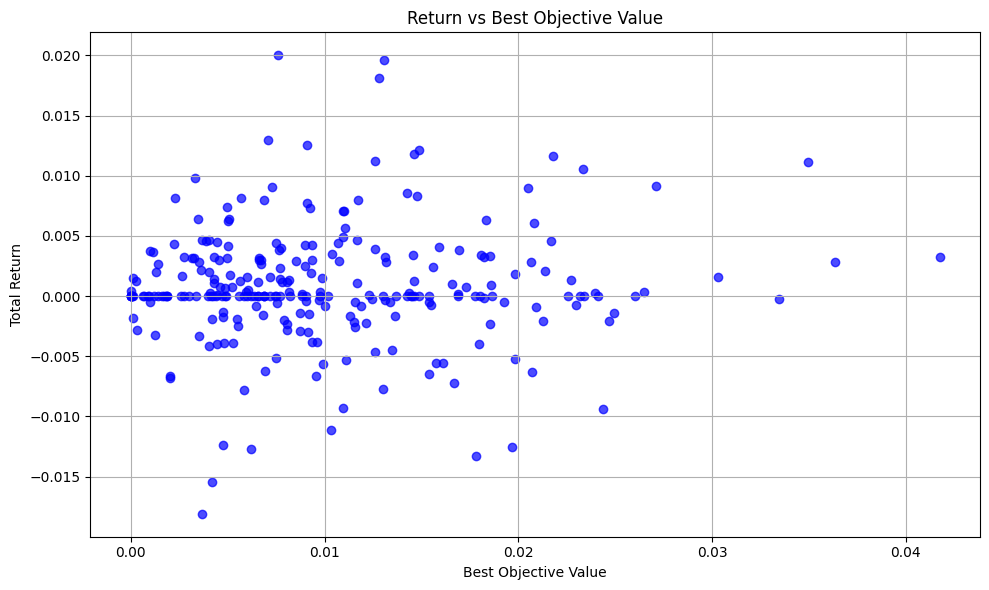

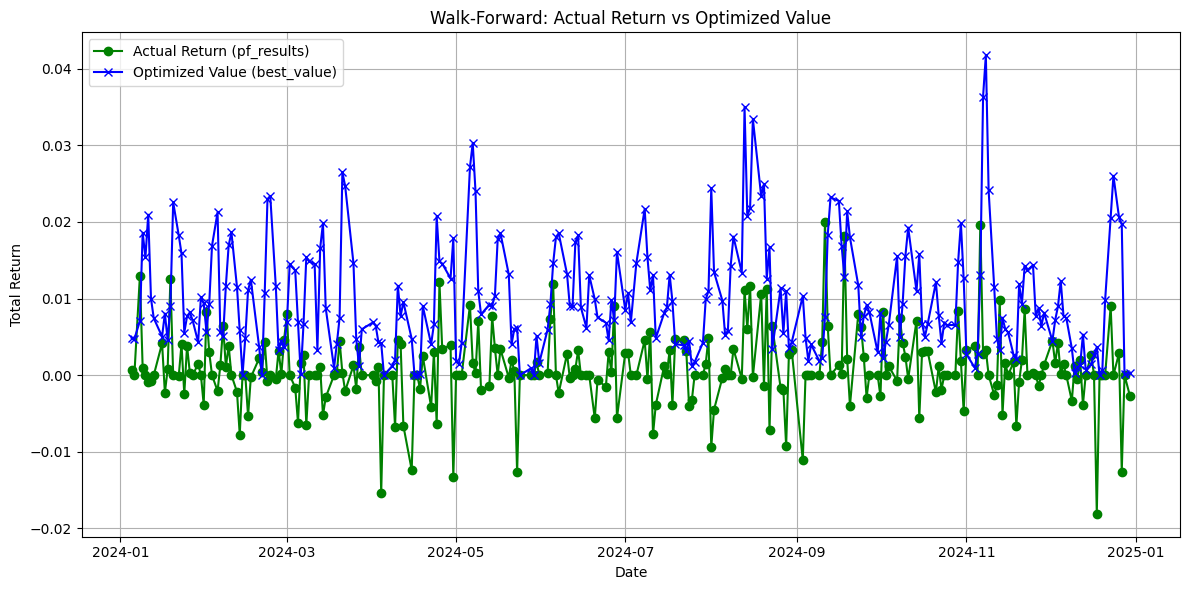

In [17]:
# Extract best_values and returns
best_values = [res["best_value"] for res in results]
returns = [res["return"] for res in results]

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(best_values, returns, c='blue', alpha=0.7)
plt.title("Return vs Best Objective Value")
plt.xlabel("Best Objective Value")
plt.ylabel("Total Return")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(results_df.index, results_df["return"], label="Actual Return (pf_results)", color="green", marker='o')
plt.plot(results_df.index, results_df["best_value"], label="Optimized Value (best_value)", color="blue", marker='x')

plt.title("Walk-Forward: Actual Return vs Optimized Value")
plt.xlabel("Date")
plt.ylabel("Total Return")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Extract total return for each daily portfolio
daily_returns = [pf.total_return() for pf in all_trades]  # e.g., 0.012, -0.008, 0.005

# Convert to growth factors
factors = [1 + r for r in daily_returns]

# Cumulative product to simulate reinvestment
cumulative_growth = np.cumprod(factors)

# Final year return
final_return = cumulative_growth[-1] - 1

print(f"Final year total return: {final_return:.2%}")


Final year total return: 23.91%


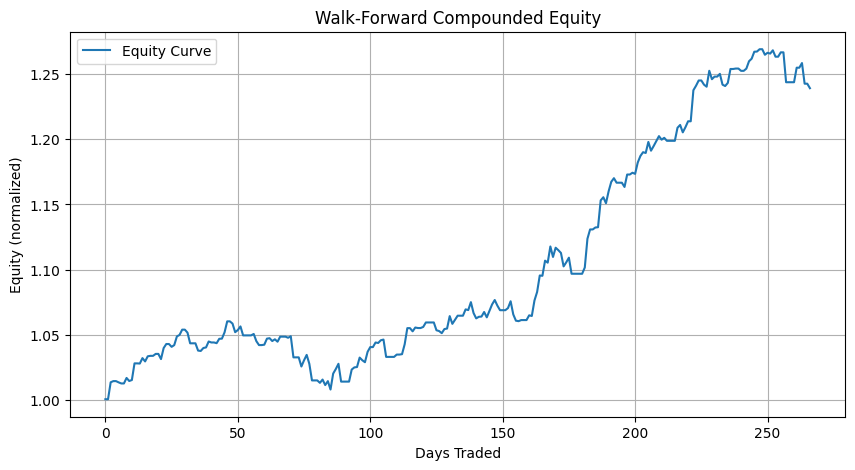

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(cumulative_growth, label="Equity Curve")
plt.title("Walk-Forward Compounded Equity")
plt.xlabel("Days Traded")
plt.ylabel("Equity (normalized)")
plt.grid(True)
plt.legend()
plt.show()
